# 5. Marketing Offer Targeting — Contextual Bandits

**The business problem:** Every time a customer lands on your site, you can offer them a discount: 0%, 10%, 20%, or 30% off. A bigger discount usually raises the chance they buy, but it also eats your margin. A single "one-size-fits-all" discount is what most companies do by default — but customers aren't identical. A loyal customer who was going to buy anyway doesn't need 30% off; a price-sensitive new visitor might need it to convert at all. **Contextual bandits** are the standard industry technique for exactly this: choosing the best action *per customer*, not one action for everyone, using only past reward feedback (no labeled "correct offer" ever exists).

## Bridging back to notebook 1

A contextual bandit is precisely notebook 1's multi-armed bandit, run **once per context**:

| Notebook 1 (plain bandit) | This notebook (contextual bandit) |
|---|---|
| One bandit problem | **One bandit problem per customer segment/context** |
| `Q[arm]` | `Q[segment][arm]` |
| Same situation every pull | Situation (context) changes every customer |
| Goal: best single arm | Goal: **best arm *for each* context** |

There's still no state transition (no notion of "next state" — every customer is an independent, one-shot decision), which is what makes this a *bandit* rather than a full MDP like Gridworld/pricing/inventory. The only new idea is that the agent gets to see **context** before acting, and can specialize its policy to it. This is one of the most widely deployed RL-adjacent techniques in industry — ad selection, article/content ranking, personalized promotions, next-best-action systems.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
plt.rcParams['figure.figsize'] = (9, 4.5)

## Step 1 — Simulate customers and a hidden "true" response model

We define 4 customer segments and, for each, a hidden (unknown to the agent) probability of converting at each discount level. This lets us later check whether the agent discovered the *right* answer, not just *an* answer.

Notice the story we've built in: **loyal, non-price-sensitive customers convert at the same 60% rate no matter the discount** — so discounting them is pure margin giveaway. **New, price-sensitive customers barely convert at 0% but convert much more with a meaningful discount** — for them, discounting is worth it. A single company-wide discount policy cannot capture both facts at once; a contextual policy can.

In [8]:
SEGMENTS = [
    "Loyal & Not price-sensitive",
    "Loyal & Price-sensitive",
    "New & Not price-sensitive",
    "New & Price-sensitive",
]
DISCOUNTS = [0.0, 0.10, 0.20, 0.30]
BASE_PRICE = 100.0
COST = 50.0
MARGIN = [BASE_PRICE * (1 - d) - COST for d in DISCOUNTS]   # [50, 40, 30, 20]

# hidden ground truth: P(convert) for each (segment, discount) -- the agent never sees this directly
# this is the probability of a customer converting (buying) given their segment and the discount offered
TRUE_CONVERSION_PROB = {
    "Loyal & Not price-sensitive": [0.60, 0.60, 0.60, 0.60],
    "Loyal & Price-sensitive":     [0.50, 0.65, 0.75, 0.80],
    "New & Not price-sensitive":   [0.25, 0.30, 0.33, 0.35],
    "New & Price-sensitive":       [0.15, 0.35, 0.55, 0.70],
}

print("*Probability of buying per segment and discount*")
print(f"{'Segment':<30}" + "".join(f"{'d=' + str(int(d*100)) + '%':>10}" for d in DISCOUNTS))
for seg in SEGMENTS:
    probability = [p for p in TRUE_CONVERSION_PROB[seg]]
    print(f"{seg:<30}" + "".join(f"{p:>10.2f}" for p in probability))
print("\n*Expected Margin per segment and discount*")
print(f"{'Segment':<30}" + "".join(f"{'d=' + str(int(d*100)) + '%':>10}" for d in DISCOUNTS))
for seg in SEGMENTS:
    expected = [p * m for p, m in zip(TRUE_CONVERSION_PROB[seg], MARGIN)]
    print(f"{seg:<30}" + "".join(f"{e:>10.2f}" for e in expected))

*Probability of buying per segment and discount*
Segment                             d=0%     d=10%     d=20%     d=30%
Loyal & Not price-sensitive         0.60      0.60      0.60      0.60
Loyal & Price-sensitive             0.50      0.65      0.75      0.80
New & Not price-sensitive           0.25      0.30      0.33      0.35
New & Price-sensitive               0.15      0.35      0.55      0.70

*Expected Margin per segment and discount*
Segment                             d=0%     d=10%     d=20%     d=30%
Loyal & Not price-sensitive        30.00     24.00     18.00     12.00
Loyal & Price-sensitive            25.00     26.00     22.50     16.00
New & Not price-sensitive          12.50     12.00      9.90      7.00
New & Price-sensitive               7.50     14.00     16.50     14.00


Those numbers are the *true expected reward* per (segment, discount) — hidden from the agent, visible to us so we can grade its homework later. Already you can see the best discount differs by segment (scan each row for the largest number).

In [9]:
def serve_customer(segment, discount_idx):
    '''Simulate one customer interaction: returns the realized reward (0 if no sale).'''
    converts = rng.random() < TRUE_CONVERSION_PROB[segment][discount_idx]
    return MARGIN[discount_idx] if converts else 0.0

In [13]:
serve_customer("Loyal & Price-sensitive", 2)  # example usage

30.0

## Step 2 — Three strategies to compare

1. **Random**: pick a random discount for every customer (no learning).
2. **Best single discount ("one-size-fits-all")**: the standard baseline — find the one discount that performs best *on average across all customers*, and give everyone that.
3. **Contextual bandit**: maintain a separate epsilon-greedy bandit *per segment*, exactly like notebook 1, and learn a specialized policy for each.

**Important:** Here the Q-learning algorith doesn't include $\gamma$, since we consider $\gamma=0$. This is because this problem focuses on immediate reward. If we lose a customer we don't get him again, and it won't be any potential benefit in the future. 

In [14]:
N_CUSTOMERS = 30_000
EPSILON = 0.1

def random_segment():
    return SEGMENTS[rng.integers(len(SEGMENTS))]

# --- Strategy 1: random ---
random_rewards = []
for _ in range(N_CUSTOMERS):
    seg = random_segment()
    a = rng.integers(len(DISCOUNTS)) # randomly choose a discount
    random_rewards.append(serve_customer(seg, a))

# --- Strategy 3: contextual bandit (also generates the stream of segments we reuse for strategy 2) ---
Q = {seg: np.zeros(len(DISCOUNTS)) for seg in SEGMENTS}
counts = {seg: np.zeros(len(DISCOUNTS)) for seg in SEGMENTS}
bandit_rewards = []
customer_stream = []   # so strategy 2 can be evaluated on an identical stream of customers

for _ in range(N_CUSTOMERS):
    seg = random_segment()
    customer_stream.append(seg)
    if rng.random() < EPSILON:
        a = rng.integers(len(DISCOUNTS)) # randomly choose a discount (exploration)
    else:
        a = int(np.argmax(Q[seg])) # choose the best known discount (exploitation)
    r = serve_customer(seg, a) # simulate the customer interaction and get the reward
    counts[seg][a] += 1
    Q[seg][a] += (r - Q[seg][a]) / counts[seg][a]
    bandit_rewards.append(r)

print(f"Random policy avg reward per customer:            {np.mean(random_rewards):.2f}")
print(f"Contextual bandit avg reward per customer:         {np.mean(bandit_rewards):.2f}")

Random policy avg reward per customer:            16.78
Contextual bandit avg reward per customer:         20.58


In [24]:
# --- Strategy 2: best single discount, chosen with the benefit of hindsight on a held-out sample ---
avg_reward_per_discount = []
for a in range(len(DISCOUNTS)):
    revs = [serve_customer(random_segment(), a) for _ in range(20_000)]
    avg_reward_per_discount.append(np.mean(revs))

best_fixed_action = int(np.argmax(avg_reward_per_discount))
print("Avg reward per customer, if every customer got that fixed discount:")
for d, r in zip(DISCOUNTS, avg_reward_per_discount):
    marker = "  <- best single discount" if d == DISCOUNTS[best_fixed_action] else ""
    print(f"  {int(d*100)}%: {r:.2f}{marker}")

print(f"\nBest single discount (with hindsight) is {int(DISCOUNTS[best_fixed_action]*100)}% with avg reward per customer: {avg_reward_per_discount[best_fixed_action]:.2f}")
one_size_fits_all_rewards = [serve_customer(seg, best_fixed_action) for seg in customer_stream]
print(f"\nOne-size-fits-all avg reward per customer (on the same customer stream): {np.mean(one_size_fits_all_rewards):.2f}")

Avg reward per customer, if every customer got that fixed discount:
  0%: 18.70
  10%: 18.96  <- best single discount
  20%: 16.75
  30%: 12.25

Best single discount (with hindsight) is 10% with avg reward per customer: 18.96

One-size-fits-all avg reward per customer (on the same customer stream): 18.94


## Step 3 — Compare cumulative reward

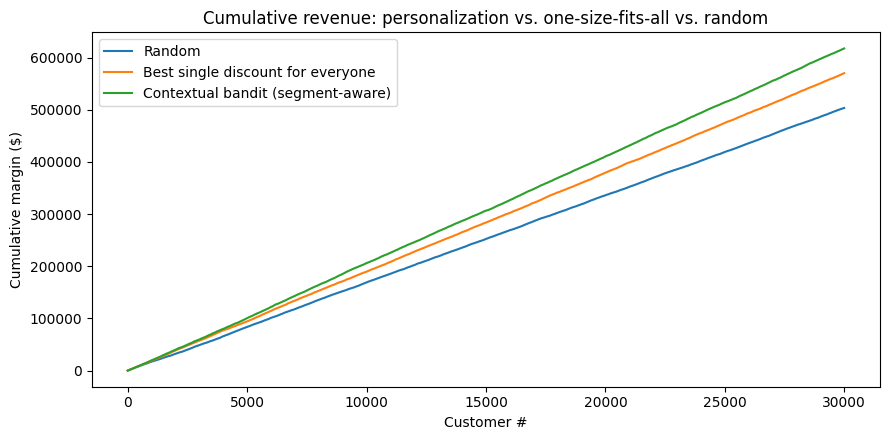

Contextual bandit improves on the best single fixed discount by 8.3% per customer.
At scale (millions of customers), that per-customer gap is the entire business case for personalization.


In [19]:
plt.figure()
plt.plot(np.cumsum(random_rewards), label="Random")
plt.plot(np.cumsum(one_size_fits_all_rewards), label="Best single discount for everyone")
plt.plot(np.cumsum(bandit_rewards), label="Contextual bandit (segment-aware)")
plt.xlabel("Customer #")
plt.ylabel("Cumulative margin ($)")
plt.title("Cumulative revenue: personalization vs. one-size-fits-all vs. random")
plt.legend()
plt.tight_layout()
plt.show()

lift_vs_best_fixed = (np.mean(bandit_rewards) / np.mean(one_size_fits_all_rewards) - 1) * 100
print(f"Contextual bandit improves on the best single fixed discount by {lift_vs_best_fixed:.1f}% per customer.")
print("At scale (millions of customers), that per-customer gap is the entire business case for personalization.")

Notice the random strategy is a straight, shallow line — it never improves. The best single fixed discount is a big step up (any company running a single sitewide promotion is at least doing this). But the contextual bandit — with no more information than "which segment is this customer in" — climbs faster still, because it stops wasting discount budget on customers who would have converted anyway, and concentrates it on the segment where it actually moves the needle.

## Step 4 — Did it learn the *right* policy per segment?

Compare the discount the bandit ends up preferring for each segment against the true best discount we know (but the agent never saw).

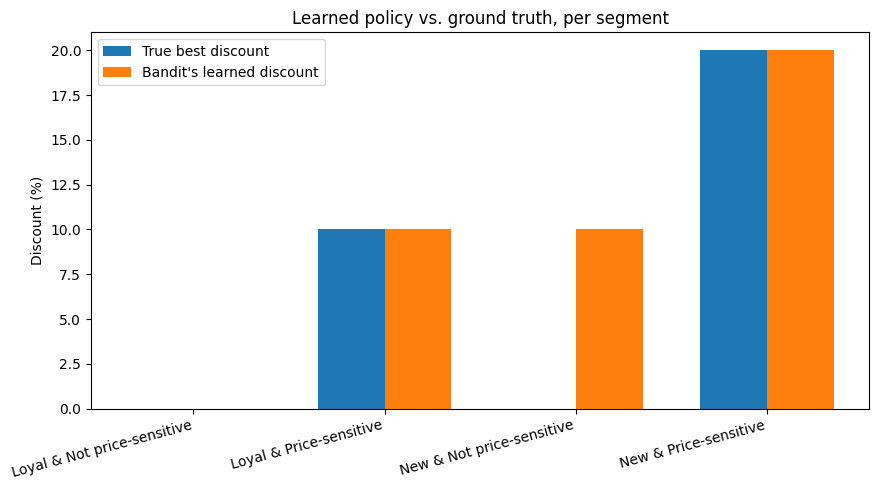

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(SEGMENTS))
width = 0.35

learned_best = [DISCOUNTS[int(np.argmax(Q[seg]))] for seg in SEGMENTS]
true_best = []
for seg in SEGMENTS:
    expected = [p * m for p, m in zip(TRUE_CONVERSION_PROB[seg], MARGIN)]
    true_best.append(DISCOUNTS[int(np.argmax(expected))])

ax.bar(x - width/2, [d*100 for d in true_best], width, label="True best discount")
ax.bar(x + width/2, [d*100 for d in learned_best], width, label="Bandit's learned discount")
ax.set_xticks(x)
ax.set_xticklabels(SEGMENTS, rotation=15, ha="right")
ax.set_ylabel("Discount (%)")
ax.set_title("Learned policy vs. ground truth, per segment")
ax.legend()
plt.tight_layout()
plt.show()

If the bars match (or are close), the bandit correctly reverse-engineered that loyal, discount-insensitive customers shouldn't be discounted, while new, price-sensitive customers should — a segmented policy no one had to hand-write, discovered purely by trying discounts and watching what converted.

## Going further: beyond a handful of discrete segments

Real customers aren't tidily bucketed into 4 segments — you usually have dozens of continuous features (recency, frequency, monetary value, browsing behavior, etc.). Once the context is continuous, a lookup table like `Q[segment][action]` no longer works — you can't have a table row for every possible customer. The standard solution is to replace the table with a **model** (often just linear regression, or a small neural net) that predicts expected reward from `(context, action)`, updated online as new interactions arrive. Two names worth knowing for an interview:

- **LinUCB** — fits a linear model per action and picks the action with the highest *upper confidence bound* on predicted reward (rewarding both high expected value and high uncertainty, to keep exploring intelligently rather than randomly like epsilon-greedy). Widely cited from Yahoo's use of it for news-article recommendation.
- **Thompson Sampling** — keeps a probability distribution over each action's expected reward and samples from it to decide; naturally balances exploration/exploitation without a manually tuned `epsilon`.

Both are drop-in replacements for the epsilon-greedy update we used here — the business framing (context in, action out, reward observed, model updated) doesn't change at all.

## Key takeaways

1. A **contextual bandit** is a set of ordinary bandits (notebook 1), one per context, sharing nothing but the same learning mechanism.
2. The realistic business benchmark isn't "no policy," it's **the best single policy applied to everyone** — and personalization has to clear that bar to earn its complexity.
3. Small per-customer gains compound at scale — the pitch for these systems is almost always framed in "$X per customer x millions of customers," not "we tripled conversion."
4. When contexts are continuous/high-dimensional rather than a handful of segments, the table becomes a model (LinUCB, Thompson Sampling, or a neural net) — same idea, different function approximator.

Last stop: **staff scheduling**, where we go back to a full MDP (state that evolves over time, like inventory) but for a resource-allocation problem — deciding how many staff to roster each period against fluctuating, uncertain demand.